# PINNs vs FD: Forward Problem (1D Wave Equation)

**Goal:** Compare Physics-Informed Neural Networks with Finite Difference for solving forward wave equation

**Problem:** 1D acoustic wave equation with a constant wave speed
$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

**Wave speed:** $c = 0.95$ m/s, the same value for both solvers

**Initial conditions:**
$$u(x, 0) = \exp\left(-25(x - 0.5)^2\right)$$
$$\frac{\partial u}{\partial t}(x, 0) = 50\,c\,(x - 0.5) \exp\left(-25(x - 0.5)^2\right)$$

These two conditions are the Gaussian pulse $u(x,t) = \exp(-25(x - 0.5 - ct)^2)$ at $t = 0$, so
the pulse travels to the right until it meets a boundary.

**Boundary conditions:**
$$u(0, t) = u(1, t) = 0$$

In [1]:
import importlib.util
import os
import platform

# JAX reads JAX_PLATFORMS when it first initialises a backend, so set it before importing jax.
# The Metal backend exists only on Apple silicon with the jax-metal plugin installed.
# Colab and Linux runners use the default backend.
def metal_available():
    if platform.system() != "Darwin":
        return False
    try:
        return importlib.util.find_spec("jax_plugins.metal_plugin") is not None
    except ModuleNotFoundError:
        return False

if metal_available():
    os.environ['JAX_PLATFORMS'] = 'metal'

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, lax
import optax
import time
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 8)
Path('figs').mkdir(parents=True, exist_ok=True)

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.10.2
JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## Method 1: Finite Difference Solver

From 06-ad.ipynb, with a constant wave speed $c$.

**Central difference scheme:**
$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + C^2 [u_{i+1}^n - 2u_i^n + u_{i-1}^n]$$

Where $C = c\Delta t / \Delta x$ is the Courant number. This explicit second-order scheme is
stable for $C \le 1$, and the cell below asserts that condition before the FD run.

In [2]:
# Spatial mesh (from 06-ad.ipynb)
n = 1000
dx = 1.0/(n-1)
dt = 5e-4
nsteps = 5000
x0 = jnp.linspace(0.0, 1.0, n)

@jit
def wave_propagation(params):
    c = params
    C = c*dt/dx
    C2 = C*C
    u0 = jnp.exp(-(5*(x0-0.5))**2)
    u1 = jnp.exp(-(5*(x0-0.5-c*dt))**2)
    u2 = jnp.zeros(n)
    
    def step(i, carry):
        u0, u1, u2 = carry
        u1p = jnp.roll(u1, 1).at[0].set(0)
        u1n = jnp.roll(u1, -1).at[n-1].set(0)
        u2 = 2 * u1 - u0 + C2*(u1p - 2*u1 + u1n)
        # Dirichlet boundary: u(0, t) = u(1, t) = 0, the condition the PINN also enforces
        u2 = u2.at[0].set(0.0).at[n-1].set(0.0)
        u0 = u1
        u1 = u2
        return (u0, u1, u2)
    
    u0, u1, u2 = lax.fori_loop(0, nsteps, step, (u0, u1, u2))
    return u2

print("✓ FD Solver ready")

✓ FD Solver ready


## Method 2: Physics-Informed Neural Network

PINN approximates $u(x,t)$ with neural network and minimizes:

$$\mathcal{L} = \mathcal{L}_{PDE} + \lambda_{IC} \mathcal{L}_{IC} + \lambda_{BC} \mathcal{L}_{BC}$$

Where:
- $\mathcal{L}_{PDE} = \left|\frac{\partial^2 u}{\partial t^2} - c^2 \frac{\partial^2 u}{\partial x^2}\right|^2$
- $\mathcal{L}_{IC}$ enforces initial conditions
- $\mathcal{L}_{BC}$ enforces boundary conditions

The collocation times are drawn as $T\,\xi^{1.2}$ with $\xi$ uniform on $[0,1]$, which puts more
points near $t = 0$ where the initial conditions have to be matched. The pulse reaches $x = 1$ at
$t \approx 0.53$ s and $x = 0$ at $t \approx 1.58$ s, so the PINN has to learn two reflections
before the final time $T = 2.5$ s.

In [3]:
# PINN for 1-D wave equation in JAX
# Matches your mesh/ICs and final time horizon

import jax
import jax.numpy as jnp
from jax import jit, grad, vmap, value_and_grad, random
import optax

# ==== Domain / mesh identical to your FD setup ====
n = 1000
dx = 1.0/(n-1)
x0 = jnp.linspace(0.0, 1.0, n)
dt = 5e-4
nsteps = 5000
T = dt * nsteps  # 2.5

# ==== Initial condition helpers (analytic, aligned with your FD shift) ====
def u0(x):
    return jnp.exp(-(5.0*(x-0.5))**2)

def ut0(x, c):
    # For u(x,t)=exp(-(5*(x-0.5-ct))^2), at t=0:
    # u_t = 50*c*(x-0.5)*exp(-(5*(x-0.5))**2)
    return 50.0 * c * (x - 0.5) * jnp.exp(-(5.0*(x-0.5))**2)

# ==== Flexible MLP with tanh or sine activations ====
def init_mlp(rng, sizes, activation="tanh", sine_w0=30.0):
    """sizes: e.g. [2, 128, 128, 128, 1]"""
    layers = []
    for idx, (in_dim, out_dim) in enumerate(zip(sizes[:-1], sizes[1:])):
        rng, k = random.split(rng)
        if activation == "sine":
            if idx == 0:
                limit = 1.0 / in_dim
            else:
                limit = jnp.sqrt(6.0 / in_dim) / sine_w0
            W = random.uniform(k, (in_dim, out_dim), minval=-limit, maxval=limit)
            b = jnp.zeros((out_dim,))
        else:
            W = random.normal(k, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim) * 0.5
            b = jnp.zeros((out_dim,))
        layers.append({"W": W, "b": b})
    return layers

def mlp_apply(layers, x, activation="tanh", sine_w0=30.0):
    z = x
    for idx, layer in enumerate(layers[:-1]):
        pre = z @ layer["W"] + layer["b"]
        if activation == "sine":
            if idx == 0:
                pre = pre * sine_w0
            z = jnp.sin(pre)
        else:
            z = jnp.tanh(pre)
    out = z @ layers[-1]["W"] + layers[-1]["b"]
    return out.squeeze(-1)

# ==== Model wrapper with input normalization to [-1, 1] on each axis ====
def xy_to_scaled(x, t, T=T):
    xs = 2.0*x - 1.0
    ts = 2.0*t/T - 1.0
    return jnp.stack([xs, ts])

def predict_u(params, x, t, activation, sine_w0):
    return mlp_apply(params["net"], xy_to_scaled(x, t, T), activation=activation, sine_w0=sine_w0)

# ==== Derivative utilities (second order in t and x) ====
# jax.grad of a jax.grad gives the second derivative directly. JAX traces the function
# again for each derivative, so there is no create_graph flag here, unlike the PyTorch
# notebooks 08a and 08c where torch.autograd.grad needs create_graph=True.
def make_u_derivs(params, activation, sine_w0):
    # Scalar function u(x,t)
    def u(x, t):
        return predict_u(params, x, t, activation, sine_w0)

    u_t = grad(lambda x, t: u(x, t), argnums=1)
    u_tt = grad(lambda x, t: u_t(x, t), argnums=1)
    u_x = grad(lambda x, t: u(x, t), argnums=0)
    u_xx = grad(lambda x, t: u_x(x, t), argnums=0)

    return u, u_t, u_tt, u_x, u_xx

# Vectorized wrappers
def vmap2(fn):
    return vmap(fn, in_axes=(0, 0))

# ==== Loss function ====
def make_loss(
    learn_c,
    c_fixed,
    *,
    activation="tanh",
    sine_w0=30.0,
    Nf=8192,
    Nb=1024,
    N0=1024,
    time_exponent=1.2,
):
    def loss_fn(params, key):
        # Unpack/derive c
        if learn_c:
            c = jnp.exp(params["log_c"])     # positivity
        else:
            c = jnp.asarray(c_fixed)

        # Sample collocation points
        key, kf, kb, k0 = random.split(key, 4)
        kf_x, kf_t = random.split(kf)
        x_f = random.uniform(kf_x, (Nf,), minval=0.0, maxval=1.0)
        t_f = T * random.uniform(kf_t, (Nf,))**time_exponent

        # Boundary points (both ends)
        t_b = random.uniform(kb, (Nb,), minval=0.0, maxval=T)
        x_b0 = jnp.zeros((Nb//2,))
        x_b1 = jnp.ones((Nb - Nb//2,))
        t_b0 = t_b[:Nb//2]
        t_b1 = t_b[Nb//2:]

        # Initial condition points at t=0
        x_i = random.uniform(k0, (N0,), minval=0.0, maxval=1.0)

        # Derivatives
        u, u_t, u_tt, u_x, u_xx = make_u_derivs(params, activation, sine_w0)

        # PDE residual at collocation points
        r = vmap2(lambda x, t: u_tt(x, t) - (c**2) * u_xx(x, t))(x_f, t_f)
        loss_pde = jnp.mean(r**2)

        # Boundary losses u(0,t)=0 and u(1,t)=0
        ub0 = vmap(lambda t: u(0.0, t))(t_b0)
        ub1 = vmap(lambda t: u(1.0, t))(t_b1)
        loss_bc = jnp.mean(ub0**2) + jnp.mean(ub1**2)

        # Initial displacement u(x,0)=u0(x)
        ui = vmap(lambda x: u(x, 0.0))(x_i)
        loss_ic_u = jnp.mean((ui - u0(x_i))**2)

        # Initial velocity u_t(x,0)=ut0(x,c)
        uit = vmap(lambda x: u_t(x, 0.0))(x_i)
        loss_ic_ut = jnp.mean((uit - ut0(x_i, c))**2)

        # Weighted sum (ICs emphasized a bit)
        loss = (1.0 * loss_pde +
                5.0 * loss_bc  +
               10.0 * loss_ic_u +
                5.0 * loss_ic_ut)

        details = {
            "loss": loss,
            "pde": loss_pde,
            "bc": loss_bc,
            "ic_u": loss_ic_u,
            "ic_ut": loss_ic_ut,
            "c": c,
        }
        return loss, details
    return loss_fn

# ==== Training driver ====
def train_pinn(
    steps=10000,
    c_init=1.0,
    learn_c=False,
    lr=1e-3,
    seed=0,
    width=128,
    depth=3,
    activation="tanh",
    sine_w0=30.0,
    Nf=8192,
    Nb=1024,
    N0=1024,
    time_exponent=1.2,
):
    rng = random.PRNGKey(seed)

    # MLP init
    sizes = [2] + [width]*depth + [1]
    rng, k = random.split(rng)
    net = init_mlp(k, sizes, activation=activation, sine_w0=sine_w0)

    # Parameter tree
    params = {"net": net}
    if learn_c:
        params["log_c"] = jnp.log(jnp.asarray(c_init))

    # Opt
    opt = optax.adam(lr)
    opt_state = opt.init(params)

    loss_fn = make_loss(
        learn_c=learn_c,
        c_fixed=c_init,
        activation=activation,
        sine_w0=sine_w0,
        Nf=Nf,
        Nb=Nb,
        N0=N0,
        time_exponent=time_exponent,
    )

    @jit
    def step(params, opt_state, key):
        (loss_val, details), grads = value_and_grad(loss_fn, has_aux=True)(params, key)
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, details

    # Train
    last_details = None
    for i in range(1, steps+1):
        rng, k = random.split(rng)
        params, opt_state, details = step(params, opt_state, k)
        last_details = details
        if i % 1000 == 0 or i == 1 or i == steps:
            print(f"iter {i:5d} | loss={float(details['loss']):.4e} "
                  f"pde={float(details['pde']):.4e} bc={float(details['bc']):.4e} "
                  f"ic_u={float(details['ic_u']):.4e} ic_ut={float(details['ic_ut']):.4e} "
                  f"c={float(details['c']):.5f}")

    return params, float(last_details["c"])

# ==== Convenience: solve and return u(x, T) on your x0 grid ====
def solve_with_pinn(
    c=1.0,
    learn_c=False,
    steps=10000,
    width=128,
    depth=3,
    lr=1e-3,
    seed=0,
    activation="tanh",
    sine_w0=30.0,
    Nf=8192,
    Nb=1024,
    N0=1024,
    time_exponent=1.2,
):
    params, c_hat = train_pinn(
        steps=steps,
        c_init=c,
        learn_c=learn_c,
        lr=lr,
        seed=seed,
        width=width,
        depth=depth,
        activation=activation,
        sine_w0=sine_w0,
        Nf=Nf,
        Nb=Nb,
        N0=N0,
        time_exponent=time_exponent,
    )
    # Evaluate at final time T on your x-grid
    u_pred_T = vmap(lambda x: predict_u(params, x, T, activation, sine_w0))(x0)
    return u_pred_T, c_hat

print("✓ PINN scaffolding ready (call solve_with_pinn(...))")


✓ PINN scaffolding ready (call solve_with_pinn(...))


## Forward Problem: Solve for $u(x,t)$

**Known:** constant wave speed $c = 0.95$ m/s

The RMSE below measures the PINN against the finite difference solution. FD is the reference
here because it is second-order accurate in both $\Delta x$ and $\Delta t$ on a 1000-point mesh
with $C = 0.475$: halving $\Delta x$ and $\Delta t$ moves its peak by $4\times10^{-5}$, far below
the PINN error. FD still carries that discretisation error, so it is a reference and not the
exact solution.

In [4]:
# --- Constant velocity (must be scalar to match current PINN + FD) ---
c_true = 0.95  # m/s

# Stability of the explicit central scheme requires C = c*dt/dx <= 1
courant = c_true * dt / dx
assert courant <= 1.0, f"CFL violated: C = {courant:.3f} > 1"

print("="*80)
print("FORWARD PROBLEM")
print("="*80)
print(f"Velocity: c = {c_true:.2f} m/s")
print(f"Courant number: C = c*dt/dx = {courant:.4f} (stable for C <= 1)")
print()

# --- Method 1: Finite Difference (warm-up + timed) ---
print("Method 1: Finite Difference")
_ = wave_propagation(c_true)           # JIT warm-up
start = time.time()
u_fd = wave_propagation(c_true)
u_fd.block_until_ready()               # ensure accurate timing
time_fd = time.time() - start
print(f"Time: {time_fd*1000:.2f} ms")
print()

# --- Method 2: PINN (sine-activated PINN tuned for this forward problem) ---
print("Method 2: PINN")
start = time.time()
u_pinn, c_hat = solve_with_pinn(
    c=c_true,
    learn_c=False,
    steps=9000,
    width=128,
    depth=4,
    lr=5e-4,
    seed=0,
    activation="sine",
    sine_w0=30.0,
    time_exponent=1.2,
)
try:
    u_pinn.block_until_ready()
except AttributeError:
    pass
time_pinn = time.time() - start
print(f"Total time: {time_pinn:.2f} s")
print(f"c_hat (echoes c when learn_c=False): {c_hat:.5f}")

# --- Error on the x0 grid (PINN already returned on x0) ---
u_pinn_interp = u_pinn  # same grid as x0
rmse = jnp.sqrt(jnp.mean((u_fd - u_pinn_interp)**2))

print()
print("="*80)
print(f"FD:   {time_fd*1000:.2f} ms")
print(f"PINN: {time_pinn:.2f} s ({time_pinn/time_fd:.0f}× slower)")
print(f"RMSE: {rmse:.2e}")
print("="*80)


FORWARD PROBLEM
Velocity: c = 0.95 m/s
Courant number: C = c*dt/dx = 0.4745 (stable for C <= 1)

Method 1: Finite Difference
Time: 5.99 ms

Method 2: PINN
iter     1 | loss=3.1117e+01 pde=9.5565e-07 bc=3.0721e-11 ic_u=2.5086e-01 ic_ut=5.7217e+00 c=0.95000
iter  1000 | loss=5.1191e-02 pde=1.5231e-02 bc=5.9092e-03 ic_u=4.4125e-04 ic_ut=4.0031e-04 c=0.95000
iter  2000 | loss=2.9343e-02 pde=2.1822e-02 bc=5.6274e-04 ic_u=4.1215e-04 ic_ut=1.1721e-04 c=0.95000
iter  3000 | loss=1.0438e-02 pde=5.9757e-03 bc=4.3737e-04 ic_u=1.9859e-04 ic_ut=5.7999e-05 c=0.95000
iter  4000 | loss=4.1597e-03 pde=1.7359e-03 bc=3.5208e-04 ic_u=5.4487e-05 ic_ut=2.3701e-05 c=0.95000
iter  5000 | loss=1.2189e-02 pde=6.3946e-03 bc=2.9142e-04 ic_u=4.6237e-05 ic_ut=7.7495e-04 c=0.95000
iter  6000 | loss=4.5226e-03 pde=2.6955e-03 bc=2.8473e-04 ic_u=2.6138e-05 ic_ut=2.8424e-05 c=0.95000
iter  7000 | loss=1.2212e-02 pde=1.0202e-02 bc=2.2267e-04 ic_u=2.7613e-05 ic_ut=1.2397e-04 c=0.95000
iter  8000 | loss=4.7766e-03 pde=3.39

## Visualization

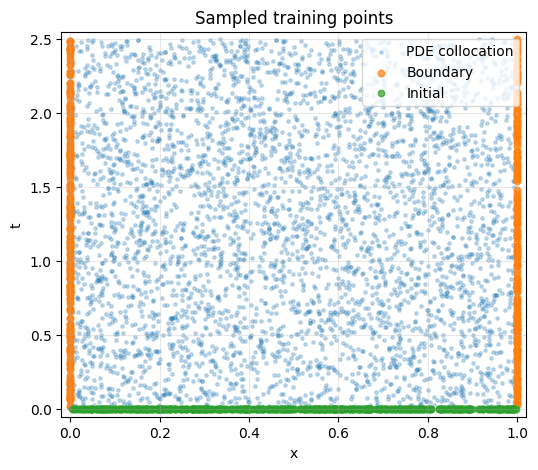

In [5]:
# Visualize a batch of PINN sample points
key_vis = random.PRNGKey(123)
_, kf_vis, kb_vis, k0_vis = random.split(key_vis, 4)
kf_vis_x, kf_vis_t = random.split(kf_vis)
Nf_vis = 4096
x_f_vis = random.uniform(kf_vis_x, (Nf_vis,), minval=0.0, maxval=1.0)
t_f_vis = random.uniform(kf_vis_t, (Nf_vis,), minval=0.0, maxval=T)
Nb_vis = 512
t_b_vis = random.uniform(kb_vis, (Nb_vis,), minval=0.0, maxval=T)
x_b0_vis = jnp.zeros((Nb_vis // 2,))
x_b1_vis = jnp.ones((Nb_vis - Nb_vis // 2,))
t_b0_vis = t_b_vis[: Nb_vis // 2]
t_b1_vis = t_b_vis[Nb_vis // 2:]
x_b_vis = jnp.concatenate([x_b0_vis, x_b1_vis])
t_b_vis = jnp.concatenate([t_b0_vis, t_b1_vis])
N0_vis = 512
x_i_vis = random.uniform(k0_vis, (N0_vis,), minval=0.0, maxval=1.0)
t_i_vis = jnp.zeros_like(x_i_vis)
xf, tf, xb, tb, xi, ti = jax.device_get((x_f_vis, t_f_vis, x_b_vis, t_b_vis, x_i_vis, t_i_vis))
plt.figure(figsize=(6, 5))
plt.scatter(xf, tf, s=6, alpha=0.25, label="PDE collocation", color="tab:blue")
plt.scatter(xb, tb, s=22, alpha=0.7, label="Boundary", color="tab:orange")
plt.scatter(xi, ti, s=22, alpha=0.7, label="Initial", color="tab:green")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Sampled training points")
plt.legend(loc="upper right")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.05, T + 0.05)
plt.grid(True, alpha=0.3)
plt.show()


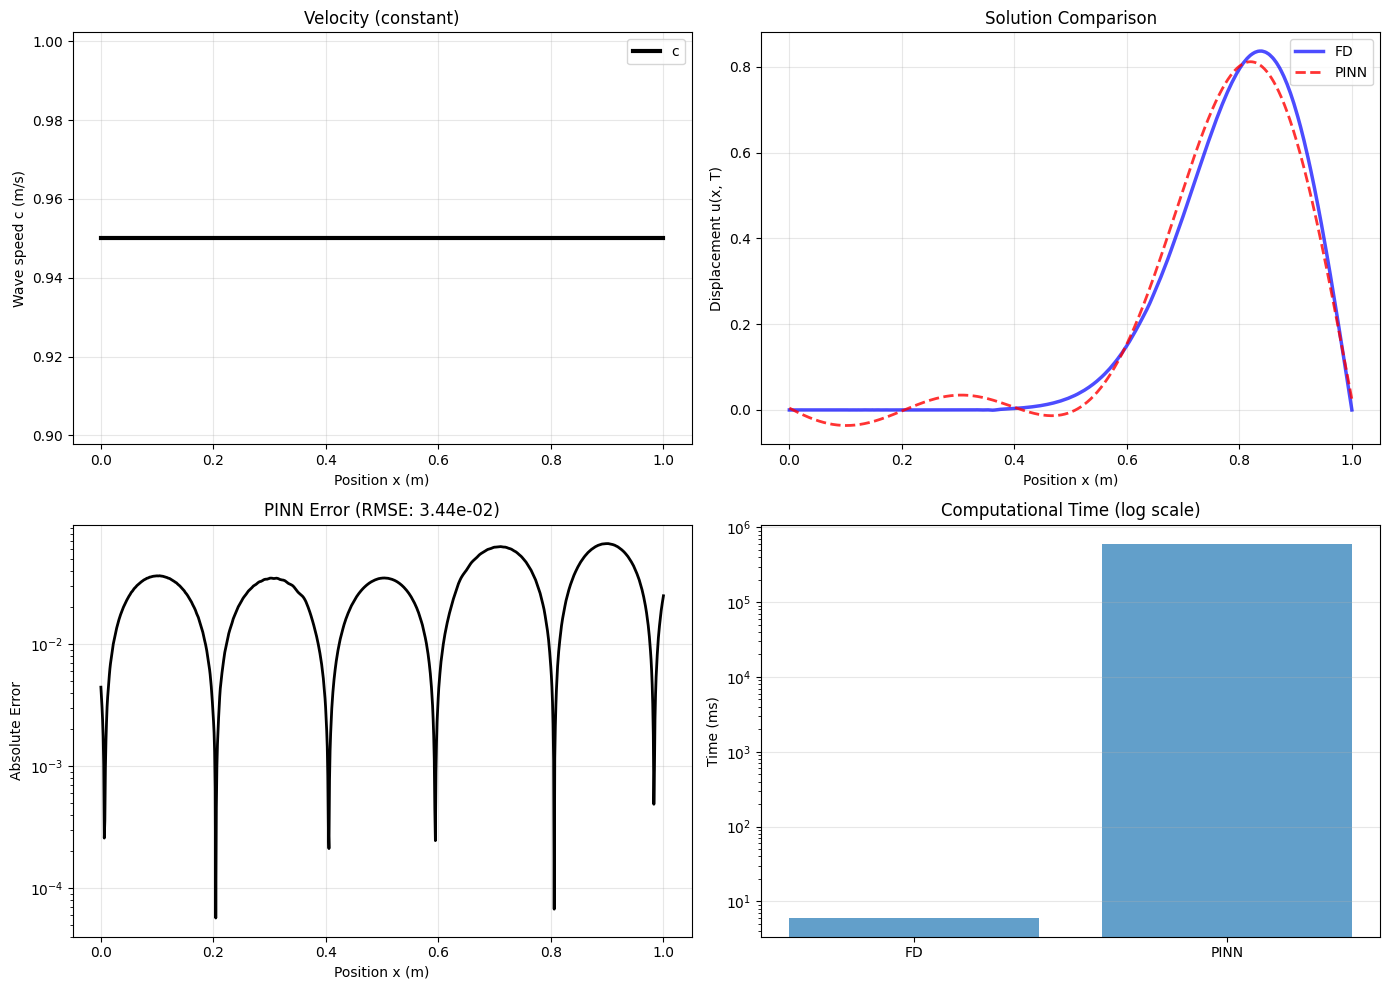

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (0,0) velocity profile (constant) ---
ax = axes[0, 0]
ax.plot(x0, jnp.full_like(x0, c_true), 'k-', linewidth=3, label='c')
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Wave speed c (m/s)')
ax.set_title('Velocity (constant)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- (0,1) solutions at final time T ---
ax = axes[0, 1]
ax.plot(x0, u_fd, 'b-', linewidth=2.5, label='FD', alpha=0.7)
ax.plot(x0, u_pinn, 'r--', linewidth=2, label='PINN', alpha=0.8)
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Displacement u(x, T)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# --- (1,0) absolute error (semilog) ---
ax = axes[1, 0]
error = jnp.abs(u_fd - u_pinn_interp)
ax.semilogy(x0, error + 1e-12, 'k-', linewidth=2)
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Absolute Error')
ax.set_title(f'PINN Error (RMSE: {rmse:.2e})')
ax.grid(True, alpha=0.3)

# --- (1,1) computational time (log scale) ---
ax = axes[1, 1]
methods = ['FD', 'PINN']
times_ms = [time_fd * 1000.0, time_pinn * 1000.0]
bars = ax.bar(methods, times_ms, alpha=0.7)
ax.set_ylabel('Time (ms)')
ax.set_title('Computational Time (log scale)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figs/pinn_forward_comparison.png', dpi=300)
plt.show()
